# Read SED fitting results

In [1]:
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

results_old = fits.open('/home/benjamin/Documents/sed_fitting/old_pop_late_burst/results.fits')
results_age = fits.open('/home/benjamin/Documents/sed_fitting/constant_sfh_age/results.fits')
results_noage = fits.open('/home/benjamin/Documents/sed_fitting/constant_sfh_noage/results.fits')
mpa_jhu = fits.open('/home/benjamin/Documents/MPA-JHU/galSpecExtra-dr8.fits')

import os
os.getcwd()

from astropy.table import Table

In [2]:
# Zoom effect
from matplotlib.transforms import (Bbox, TransformedBbox,
                                   blended_transform_factory)
from mpl_toolkits.axes_grid1.inset_locator import (BboxConnector,
                                                   BboxConnectorPatch,
                                                   BboxPatch)


def connect_bbox(bbox1, bbox2,
                 loc1a, loc2a, loc1b, loc2b,
                 prop_lines, prop_patches=None):
    if prop_patches is None:
        prop_patches = {
            **prop_lines,
            "alpha": prop_lines.get("alpha", 1) * 0.2,
            "clip_on": False,
        }

    c1 = BboxConnector(
        bbox1, bbox2, loc1=loc1a, loc2=loc2a, clip_on=False, **prop_lines)
    c2 = BboxConnector(
        bbox1, bbox2, loc1=loc1b, loc2=loc2b, clip_on=False, **prop_lines)

    bbox_patch1 = BboxPatch(bbox1, **prop_patches)
    bbox_patch2 = BboxPatch(bbox2, **prop_patches)

    p = BboxConnectorPatch(bbox1, bbox2,
                           loc1a=loc1a, loc2a=loc2a, loc1b=loc1b, loc2b=loc2b,
                           clip_on=False,
                           **prop_patches)

    return c1, c2, bbox_patch1, bbox_patch2, p


def zoom_effect01(ax1, ax2, xmin, xmax, **kwargs):
    """
    Connect *ax1* and *ax2*. The *xmin*-to-*xmax* range in both axes will
    be marked.

    Parameters
    ----------
    ax1
        The main axes.
    ax2
        The zoomed axes.
    xmin, xmax
        The limits of the colored area in both plot axes.
    **kwargs
        Arguments passed to the patch constructor.
    """

    bbox = Bbox.from_extents(xmin, 0, xmax, 1)

    mybbox1 = TransformedBbox(bbox, ax1.get_xaxis_transform())
    mybbox2 = TransformedBbox(bbox, ax2.get_xaxis_transform())

    prop_patches = {**kwargs, "ec": "none", "alpha": 0.2}

    c1, c2, bbox_patch1, bbox_patch2, p = connect_bbox(
        mybbox1, mybbox2,
        loc1a=3, loc2a=2, loc1b=4, loc2b=1,
        prop_lines=kwargs, prop_patches=prop_patches)

    ax1.add_patch(bbox_patch1)
    ax2.add_patch(bbox_patch2)
    ax2.add_patch(c1)
    ax2.add_patch(c2)
    ax2.add_patch(p)

    return c1, c2, bbox_patch1, bbox_patch2, p


def zoom_effect02(ax1, ax2, **kwargs):
    """
    ax1 : the main axes
    ax1 : the zoomed axes

    Similar to zoom_effect01.  The xmin & xmax will be taken from the
    ax1.viewLim.
    """

    tt = ax1.transScale + (ax1.transLimits + ax2.transAxes)
    trans = blended_transform_factory(ax2.transData, tt)

    mybbox1 = ax1.bbox
    mybbox2 = TransformedBbox(ax1.viewLim, trans)

    prop_patches = {**kwargs, "ec": "none", "alpha": 0.2}

    c1, c2, bbox_patch1, bbox_patch2, p = connect_bbox(
        mybbox1, mybbox2,
        loc1a=3, loc2a=2, loc1b=4, loc2b=1,
        prop_lines=kwargs, prop_patches=prop_patches)

    ax1.add_patch(bbox_patch1)
    ax2.add_patch(bbox_patch2)
    ax2.add_patch(c1)
    ax2.add_patch(c2)
    ax2.add_patch(p)

    return c1, c2, bbox_patch1, bbox_patch2, p

# Comparing fits

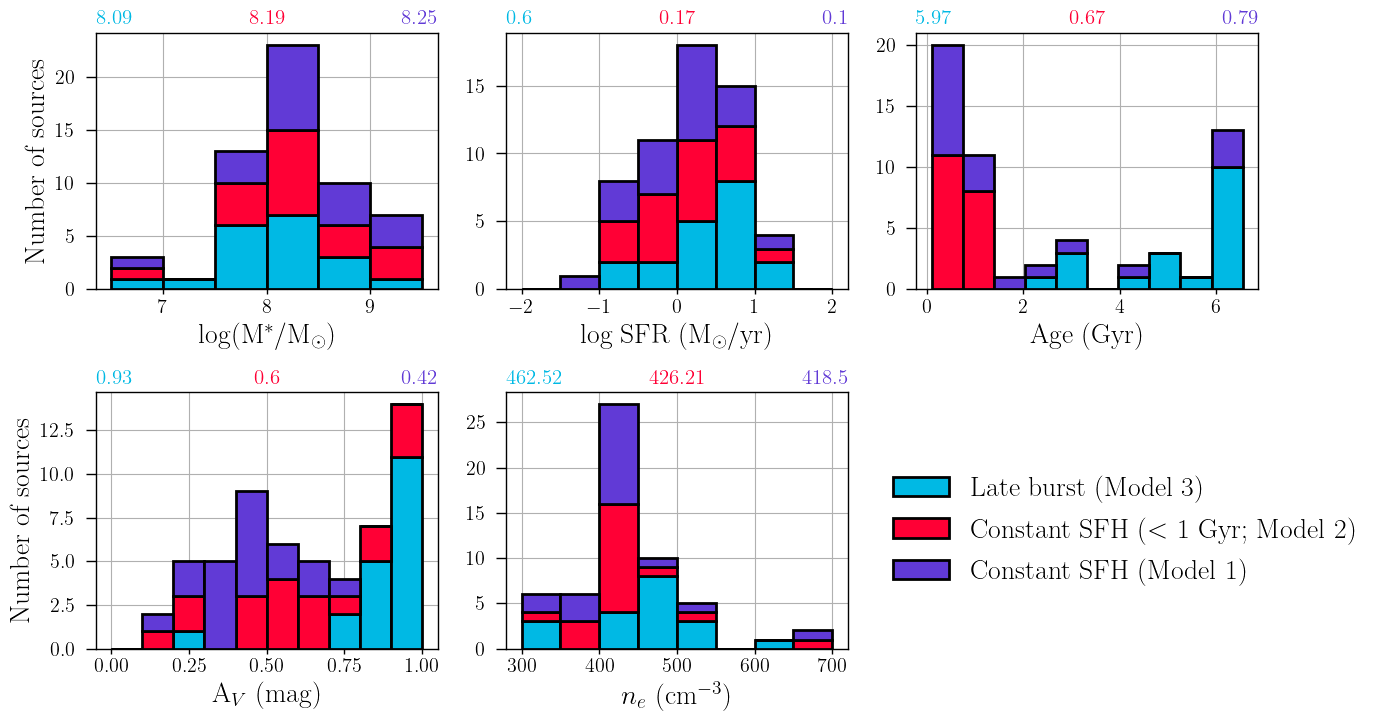

In [7]:
texPlot('on')

fig, axs = plt.subplots(2, 3)
fig.set_size_inches(15, 8)
fig.subplots_adjust(hspace=0.4)

# Stellar Mass
bin_mstar = np.arange(6.5, 10.0, 0.5)
axs[0, 0].grid(True, zorder=0)
axs[0, 0].hist([np.log10(results_old[1].data['bayes.stellar.m_star']),
          np.log10(results_age[1].data['bayes.stellar.m_star']),
          np.log10(results_noage[1].data['bayes.stellar.m_star'])], bins=bin_mstar,
        histtype='barstacked', lw =2, edgecolor='black', color=(c[0], c[1], c[2]), zorder=5,
           label=('Late burst (Model 3)', 'Constant SFH ($<$ 1 Gyr; Model 2)', 'Constant SFH (Model 1)'))
axs[0, 0].set_xlabel(r'log(M$^{*}$/M$_{\odot}$)')
axs[0, 0].set_ylabel('Number of sources')

axs[0, 0].set_title(np.round(np.median(np.log10(results_old[1].data['bayes.stellar.m_star'])), 2),
                 color=c[0], zorder=10, fontsize=15, loc='Left')
axs[0, 0].set_title(np.round(np.median(np.log10(results_age[1].data['bayes.stellar.m_star'])), 2),
                 color=c[1], zorder=10, fontsize=15)
axs[0, 0].set_title(np.round(np.median(np.log10(results_noage[1].data['bayes.stellar.m_star'])), 2),
                 color=c[2], zorder=10, fontsize=15, loc='Right')


# SFR 
bin_sfr = np.arange(-2.0, 2.5, 0.5)
axs[0, 1].grid(True, zorder=0)
axs[0, 1].hist([np.log10(results_old[1].data['bayes.sfh.sfr']),
                np.log10(results_age[1].data['bayes.sfh.sfr']),
                np.log10(results_noage[1].data['bayes.sfh.sfr'])], bins=bin_sfr,
        histtype='barstacked', lw =2, edgecolor='black', color=(c[0], c[1], c[2]), zorder=5)
axs[0, 1].set_xlabel(r'log SFR (M$_{\odot}$/yr)')

axs[0,  1].set_title(np.round(np.median(np.log10(results_old[1].data['bayes.sfh.sfr'])), 2),
                   color=c[0], zorder=10, fontsize=15, loc='Left')
axs[0,  1].set_title(np.round(np.median(np.log10(results_age[1].data['bayes.sfh.sfr'])), 2), 
                   color=c[1], zorder=10, fontsize=15)
axs[0,  1].set_title(np.round(np.median(np.log10(results_noage[1].data['bayes.sfh.sfr'])), 2), 
                   color=c[2], zorder=10, fontsize=15, loc='Right')

# Av
bin_av = np.arange(0.0, 1.1, 0.1)
axs[1, 0].grid(True, zorder=0)
axs[1, 0].hist([3.1 * results_old[1].data['bayes.attenuation.E_BVs'] / 0.44,
                3.1 * results_age[1].data['bayes.attenuation.E_BVs'] / 0.44,
                3.1 * results_noage[1].data['bayes.attenuation.E_BVs'] / 0.44], bins=bin_av,
        histtype='barstacked', lw =2, edgecolor='black', color=(c[0], c[1], c[2]), zorder=5)
axs[1, 0].set_xlabel(r'A$_{V}$ (mag)')
axs[1, 0].set_ylabel('Number of sources')

axs[1, 0].set_title(np.round(np.median(3.1 * results_old[1].data['bayes.attenuation.E_BVs'] / 0.44), 2),
              color=c[0], zorder=10, fontsize=15, loc='Left')
axs[1, 0].set_title(np.round(np.median(3.1 * results_age[1].data['bayes.attenuation.E_BVs'] / 0.44), 2),
              color=c[1], zorder=10, fontsize=15)
axs[1, 0].set_title(np.round(np.median(3.1 * results_noage[1].data['bayes.attenuation.E_BVs'] / 0.44), 2),
              color=c[2], zorder=10, fontsize=15, loc='Right')


# Electron density
bin_ne = np.arange(300, 750, 50)
axs[1, 1].grid(True, zorder=0)
axs[1, 1].hist([results_old[1].data['bayes.nebular.ne'],
                results_age[1].data['bayes.nebular.ne'],
                results_noage[1].data['bayes.nebular.ne']], bins=bin_ne,
        histtype='barstacked', lw =2, edgecolor='black', color=(c[0], c[1], c[2]), zorder=5)
axs[1, 1].set_xlabel(r'$n_{e}$ (cm$^{-3}$)')

axs[1, 1].set_title(np.round(np.median(results_old[1].data['bayes.nebular.ne']), 2), 
               color=c[0], zorder=10, fontsize=15, loc='Left')
axs[1, 1].set_title(np.round(np.median(results_age[1].data['bayes.nebular.ne']), 2), 
               color=c[1], zorder=10, fontsize=15)
axs[1, 1].set_title(np.round(np.median(results_noage[1].data['bayes.nebular.ne']), 2), 
               color=c[2], zorder=10, fontsize=15, loc='Right')

# Age
bin_age = np.arange(0, 10, 1)
axs[0, 2].grid(True, zorder=0)
axs[0, 2].hist([results_old[1].data['bayes.sfh.age']/1000,
                results_age[1].data['bayes.sfh.age']/1000,
                results_noage[1].data['bayes.sfh.age']/1000],
        histtype='barstacked', lw =2, edgecolor='black', color=(c[0], c[1], c[2]), zorder=5)
axs[0, 2].set_xlabel(r'Age (Gyr)')

axs[0, 2].set_title(np.round(np.median(results_old[1].data['bayes.sfh.age']/1000), 2),
               color=c[0], zorder=10, fontsize=15, loc='Left')
axs[0, 2].set_title(np.round(np.median(results_age[1].data['bayes.sfh.age']/1000), 2),
               color=c[1], zorder=10, fontsize=15)
axs[0, 2].set_title(np.round(np.median(results_noage[1].data['bayes.sfh.age']/1000), 2),
               color=c[2], zorder=10, fontsize=15, loc='Right')

# Off axis
axs[1, 2].axis('off')
axs[0, 0].legend(loc=(2.3, -1.2), fontsize=20)

fig.savefig('/home/benjamin/Documents/analogs/imges/sed_fitting/sed_results.pdf',
           bbox_inches='tight')

 ---- 

# Table of results

In [3]:
results_old[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  650 / length of dimension 1                          
NAXIS2  =                   27 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   81 / number of table fields                         
TTYPE1  = 'id      '                                                            
TFORM1  = '10A     '                                                            
TTYPE2  = 'bayes.attenuation.E_BVs'                                             
TFORM2  = 'D       '                                                            
TUNIT2  = 'mag     '        

In [45]:
m_star = upy.log10(upy.uarray(results_old[1].data['bayes.stellar.m_star'], results_old[1].data['bayes.stellar.m_star_err']))
sfr = upy.log10(upy.uarray(results_old[1].data['bayes.sfh.sfr'], results_old[1].data['bayes.sfh.sfr_err']))
age = upy.uarray(results_old[1].data['bayes.sfh.age']/1000, results_old[1].data['bayes.sfh.age_err']/1000)
Av = 3.1 * upy.uarray(results_old[1].data['bayes.attenuation.E_BVs'], results_old[1].data['bayes.attenuation.E_BVs_err']) / 0.44
ne = upy.uarray(results_old[1].data['bayes.nebular.ne'], results_old[1].data['bayes.nebular.ne_err'])
logU = results_old[1].data['best.nebular.logU']
red_chi2 = np.array(results_old[1].data['best.reduced_chi_square'])

In [33]:
# RA order mask
ra_order = np.argsort(results_old[1].data['id'])

dict_sed_results = {'ID': results_old[1].data['id'][ra_order],
                    'Age': age[ra_order],
                    'logM': m_star[ra_order],
                    'logSFR': sfr[ra_order],
                    'Av': Av[ra_order],
                    'ne': ne[ra_order],
                    'red_chi2': red_chi2[ra_order]
}

In [42]:
dict_sed_results_pd = pd.DataFrame(data=dict_sed_results)

In [54]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
# dict_sed_results_pd.to_latex(index=False, float_format='{:.0f}'.format, escape=False)
dict_sed_results_pd.to_csv(homedir + 'CSV_files/mage_results.csv')

---

In [ ]:
specobjID = {'J2225': 422244936562272256,
             'J2215': 1243134008619984896,
             'J0240': 513494502204270592,
             'J0021': 439223316213950464,
             'J0950': 300731025703593984,
             'J1146': 318786936665827328,
             'J1226': 3242617920756410368,
             'J1444': 661039343871223808,
             'J1448': 346799464301750272,
             'J2101': 717307953417316352,
             'J2119': 1111371552277948416,
             'J0023': 735339668748396544,
             'J0136': 1691125637219117056,
             'J0252': 797248221209454592,
             'J0305': 798423599642863616,
             'J2212': 1243114217410684928,
             'J2337': 767911057829160960,
             'J1624': 409879001813772288 }

In [2]:
results[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  655 / length of dimension 1                          
NAXIS2  =                   19 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   81 / number of table fields                         
TTYPE1  = 'id      '                                                            
TFORM1  = '15A     '                                                            
TTYPE2  = 'bayes.attenuation.E_BVs'                                             
TFORM2  = 'D       '                                                            
TUNIT2  = 'mag     '        

In [5]:

J0023_spec = pd.read_csv(homedir + 'nava_data/analogs/specs/final_spec/J0023.csv')

In [4]:
mpa_jhu_m = []
mpa_jhu_m16 = []
mpa_jhu_m84 = []

for ID in results_old[1].data['id'][:17]:
    
    # What I have to do when a companion is in the data...
    galid = ''
    try:
        galid = ID[0:5] + ID[10:]
    except:
        galid = ID[0:5]
    
    objID = specobjID[galid]
    mask = (mpa_jhu[1].data['SPECOBJID'] == str(objID))
    m_star = mpa_jhu[1].data['LGM_TOT_P50'][mask]
    m_star16 = mpa_jhu[1].data['LGM_TOT_P16'][mask]
    m_star84 = mpa_jhu[1].data['LGM_TOT_P84'][mask]

    mpa_jhu_m.append(m_star[0] + np.log10(0.61/0.66))
    mpa_jhu_m16.append(m_star16[0]+ np.log10(0.61/0.66))
    mpa_jhu_m84.append(m_star84[0]+ np.log10(0.61/0.66))
    
mpa_jhu_m = np.array(mpa_jhu_m)
mpa_jhu_m16 = np.array(mpa_jhu_m16)
mpa_jhu_m84 = np.array(mpa_jhu_m84)

In [5]:
asymmetric_error = np.array(list(zip(mpa_jhu_m - mpa_jhu_m16,
                                     mpa_jhu_m84 - mpa_jhu_m))).T

In [6]:
unc_m_star = unumpy.uarray(results[1].data['bayes.stellar.m_star'], results[1].data['bayes.stellar.m_star_err'])
m_star = unumpy.nominal_values(unumpy.log10(unc_m_star))
m_star_err = unumpy.std_devs(unumpy.log10(unc_m_star))

NameError: name 'unumpy' is not defined

Text(0.5, 0, 'log(M / M$_{\\odot}$)')

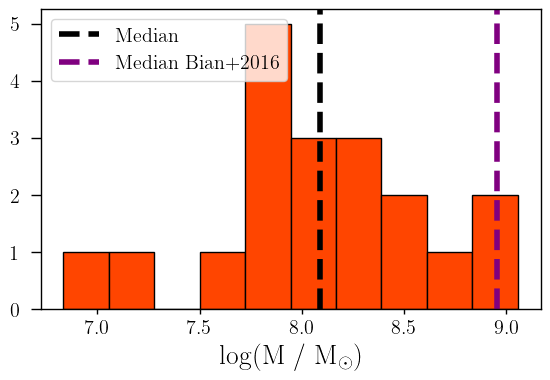

In [7]:
texPlot('on')
fig = plt.figure(figsize=(10, 6))
ax = fig.add_axes([0., 0., 0.5, 0.5])
ax.hist(np.log10(results[1].data['bayes.stellar.m_star']), #bins=np.arange(7.25, 10, 0.25),
            edgecolor='black', facecolor='orangered')
ax.axvline(np.median(m_star), ls='--', lw=4, color='black', label='Median')
ax.axvline(8.9542, ls='--', lw=4, color='purple', label='Median Bian+2016')
ax.legend(frameon=True)
ax.set_xlabel(r'log(M / M$_{\odot}$)')
#plt.savefig('/home/benjamin/Documents/analogs/masses_jpg', bbox_inches='tight', facecolor='white')

Text(0.5, 0, 'best($M_{young}$) $\\times$ Age / best($M_{tot}$)')

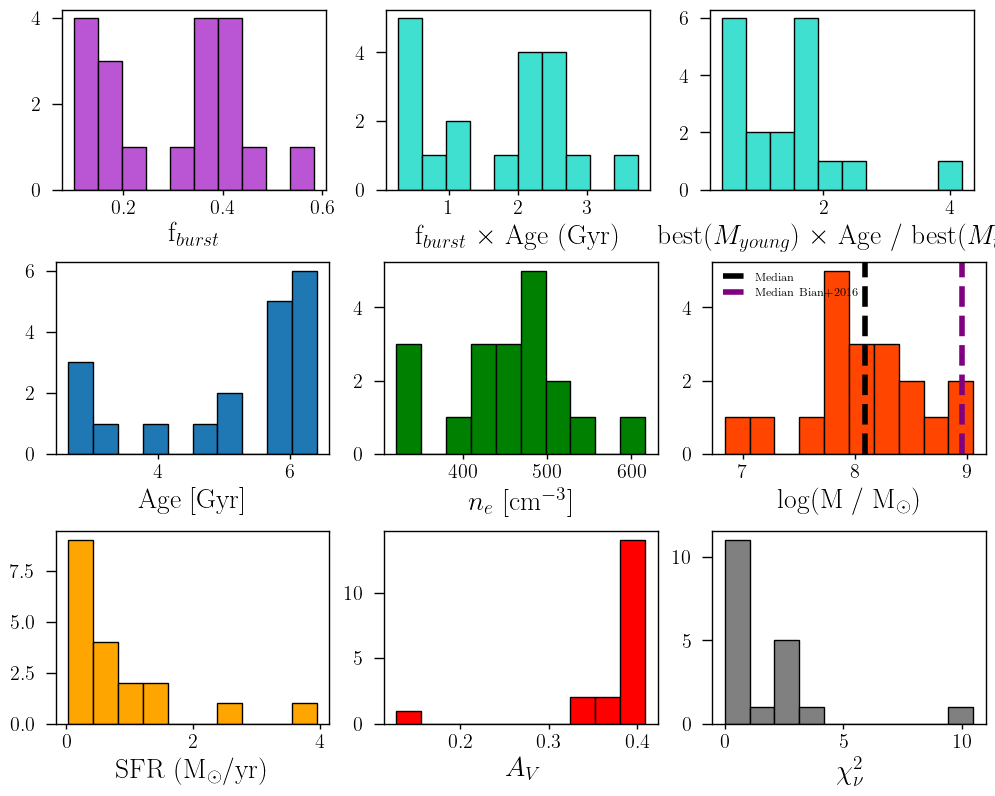

In [8]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches((12, 6))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

axs[0, 0].hist(results[1].data['bayes.sfh.age']/1000, #bins=np.arange(0, 8.5, 1),
         edgecolor='black')
axs[0, 0].set_xlabel('Age [Gyr]')

axs[0, 1].hist(results[1].data['bayes.nebular.ne'], #bins=np.arange(200, 800, 80),
         edgecolor='black', facecolor='green')
axs[0, 1].set_xlabel(r'$n_{e}$ [cm$^{-3}$]')

axs[0, 2].hist(np.log10(results[1].data['bayes.stellar.m_star']), #bins=np.arange(7.25, 10, 0.25),
            edgecolor='black', facecolor='orangered')
axs[0, 2].axvline(np.median(m_star), ls='--', lw=4, label='Median')
axs[0, 2].axvline(8.9542, ls='--', lw=4, color='purple', label='Median Bian+2016')
axs[0, 2].legend(fontsize='small')
axs[0, 2].set_xlabel(r'log(M / M$_{\odot}$)')

axs[1, 0].hist(results[1].data['bayes.sfh.sfr100Myrs'], #bins=np.arange(0, 20, 2),
         edgecolor='black', facecolor='orange')
axs[1, 0].set_xlabel(r'SFR (M$_{\odot}$/yr)')

axs[1, 1].hist(3.1 * results[1].data['bayes.attenuation.E_BVs'], #bins=np.arange(0.05, 0.4, 0.05),
               edgecolor='black', facecolor='red')
axs[1, 1].set_xlabel(r'$A_{V}$')

axs[1, 2].hist(results[1].data['best.reduced_chi_square'],
              edgecolor='black', facecolor='gray')
axs[1, 2].set_xlabel(r'$\chi^{2}_{\nu}$')

ax_extra = fig.add_axes([0.13, 1, 0.22, 0.3])
ax_extra.hist(results[1].data['bayes.sfh.f_burst'],
             edgecolor='black', facecolor='mediumorchid')
ax_extra.set_xlabel(r'f$_{burst}$')

ax_extra1 = fig.add_axes([0.40, 1, 0.22, 0.3])
ax_extra1.hist(results[1].data['bayes.sfh.f_burst'] * results[1].data['bayes.sfh.age']/1000,
             edgecolor='black', facecolor='turquoise')
ax_extra1.set_xlabel(r'f$_{burst}$ $\times$ Age (Gyr)')

ax_extra2 = fig.add_axes([0.67, 1, 0.22, 0.3])
ax_extra2.hist(results[1].data['best.stellar.m_star_young'] * (results[1].data['bayes.sfh.age']/1000) / results[1].data['bayes.stellar.m_star'],
             edgecolor='black', facecolor='turquoise')
ax_extra2.set_xlabel(r'best($M_{young}$) $\times$ Age / best($M_{tot}$)')

#plt.savefig('/home/benjamin/Documents/analogs/results/sed_fitting/old_pop_late_burst/old_pop_late_burst_hist.jpg', bbox_inches='tight');

In [9]:
dust_cal = pd.read_csv('/home/benjamin/Documents/analogs/results/dust_norm_cal_lines.csv')

In [10]:
dust_cal['galname']

0     J0021
1     J0023
2     J0136
3     J0240
4     J0252
5     J0305
6     J0950
7     J1146
8     J1226
9     J1444
10    J1448
11    J1624
12    J2101
13    J2119
14    J2212
15    J2215
16    J2225
17    J2337
Name: galname, dtype: object

In [11]:
results[1].data['bayes.attenuation.E_BVs'][np.argmax(results[1].data['id'] == results[1].data['id'][0])]

0.12984893968696995

In [12]:
ids = np.concatenate((results[1].data['id'][:-3], results[1].data['id'][-2:]))

In [13]:

E_BV_SED = []
E_BV_cal = []
for ID in ids:
    galid = ID[0:5]
    E_BV_SED.append(results[1].data['bayes.attenuation.E_BVs'][np.argmax(results[1].data['id'] == ID)] / 0.44)
    E_BV_cal.append(dust_cal['E_BV'][np.argmax(dust_cal['galname'] == galid)])
    

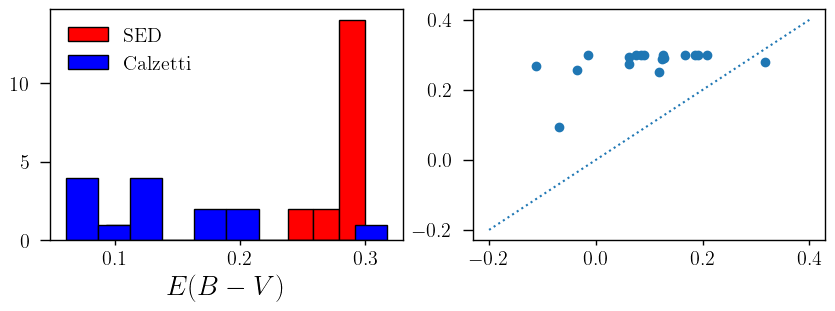

In [14]:
fig, axs = plt.subplots(1, 2)
fig.set_size_inches((10, 3))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

axs[0].hist(results[1].data['bayes.attenuation.E_BVs']/0.44,
               edgecolor='black', facecolor='red', label='SED')
axs[0].hist(dust_cal['E_BV'][dust_cal['E_BV'] > 0],
               edgecolor='black', facecolor='blue', label='Calzetti')
axs[0].set_xlabel(r'$E(B-V)$')
axs[0].legend()

axs[1].scatter(E_BV_cal, E_BV_SED)
axs[1].plot(np.arange(-0.2, 0.4, 0.01), np.arange(-0.2, 0.4, 0.01), ls=':')

Text(0.5, 0, 'log(M / M$_{\\odot}$) (CIGALE)')

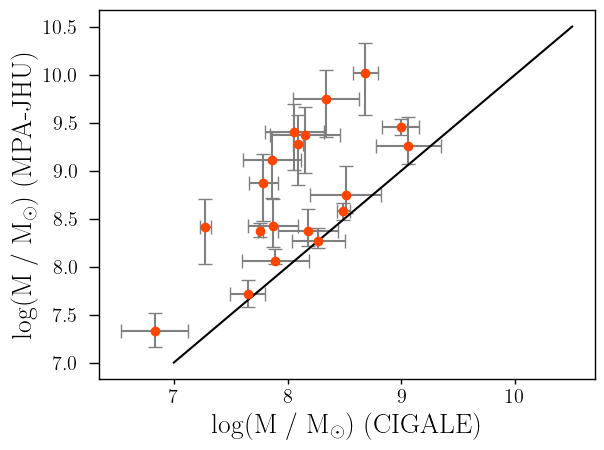

In [15]:
plt.figure()
plt.errorbar(m_star, mpa_jhu_m, xerr=m_star_err, yerr=asymmetric_error,
                   fmt='o', capsize=5, color='orangered', ecolor='gray')
plt.plot([7, 10.5], [7, 10.5], color='black')
plt.ylabel(r'log(M / M$_{\odot}$) (MPA-JHU)')
plt.xlabel(r'log(M / M$_{\odot}$) (CIGALE)')

#plt.savefig('/home/benjamin/Documents/analogs/results/sed_fitting/old_pop_late_burst/old_pop_late_burst_mass.pdf', bbox_inches='tight');

In [16]:
unc_m_star2 = unumpy.uarray(results2[1].data['bayes.stellar.m_star'], results2[1].data['bayes.stellar.m_star_err'])
m_star2 = unumpy.nominal_values(unumpy.log10(unc_m_star2))
m_star2_err = unumpy.std_devs(unumpy.log10(unc_m_star2))

In [17]:
unc_m_star3 = unumpy.uarray(results3[1].data['bayes.stellar.m_star'], results3[1].data['bayes.stellar.m_star_err'])
m_star3 = unumpy.nominal_values(unumpy.log10(unc_m_star3))
m_star3_err = unumpy.std_devs(unumpy.log10(unc_m_star3))

Text(0.5, 0, 'log(M / M$_{\\odot}$) (Old population + late burst)')

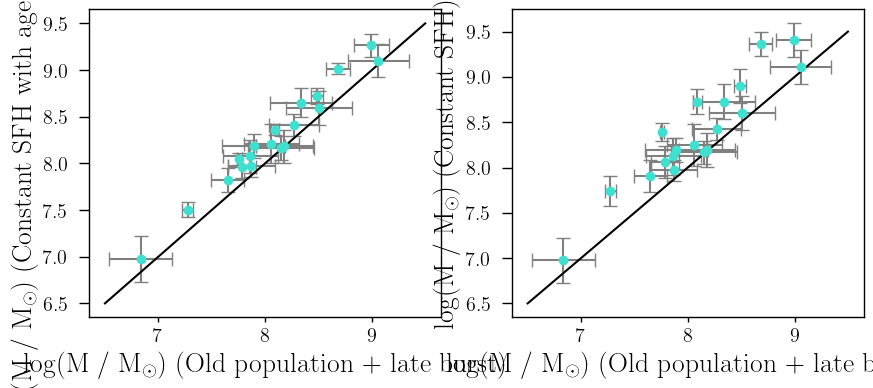

In [18]:
fig, (ax, ax1) = plt.subplots(1, 2)
fig.set_size_inches(10, 4)
ax.errorbar(m_star, m_star2, xerr=m_star_err, yerr=m_star2_err,
                   fmt='o', capsize=5, color='turquoise', ecolor='gray')
ax.plot([6.5, 9.5], [6.5, 9.5], color='black')
ax.set_ylabel(r'log(M / M$_{\odot}$) (Constant SFH with age < 1 Gyr)')
ax.set_xlabel(r'log(M / M$_{\odot}$) (Old population + late burst)')

ax1.errorbar(m_star, m_star3, xerr=m_star_err, yerr=m_star3_err,
                   fmt='o', capsize=5, color='turquoise', ecolor='gray')
ax1.plot([6.5, 9.5], [6.5, 9.5], color='black')
ax1.set_ylabel(r'log(M / M$_{\odot}$) (Constant SFH)')
ax1.set_xlabel(r'log(M / M$_{\odot}$) (Old population + late burst)')
#plt.savefig('/home/benjamin/Documents/analogs/results/mass_comparison.png', bbox_inches='tight')

In [20]:
mask = results[1].data['id'] == 'J0023-0948'

flux_model_mJy = []
flux_obs_mJy = []

flux_model = []
flux_obs = []

age = ufloat(results[1].data['bayes.sfh.age'][mask][0], results[1].data['bayes.sfh.age_err'][mask][0]) / 1000
mass = unumpy.log10(ufloat(results[1].data['bayes.stellar.m_star'][mask][0], results[1].data['bayes.stellar.m_star_err'][mask][0]))
att = 3.1 * ufloat(results[1].data['bayes.attenuation.E_BVs'][mask][0], results[1].data['bayes.attenuation.E_BVs_err'][mask][0])
sfr = ufloat(results[1].data['bayes.sfh.sfr'][mask][0], results[1].data['bayes.sfh.sfr_err'][mask][0])
red_chi2 = round(results[1].data['best.reduced_chi_square'][mask][0], 2)
for i in range(len(filts)):
    fl_model_mJy = results[1].data['bayes.'+filts[i]+'_prime'][mask][0]
    flux_model_mJy.append(fl_model_mJy)
    fl_obs_mJy = input_data[filts[i]+'_prime'][mask]
    flux_obs_mJy.append(fl_obs_mJy)
    flux_model.append(1e-18 * fl_model_mJy * 299792458 * 100 / (center[i]**2))
    flux_obs.append(1e-18 * float(fl_obs_mJy) * 299792458 * 100 / (center[i]**2))

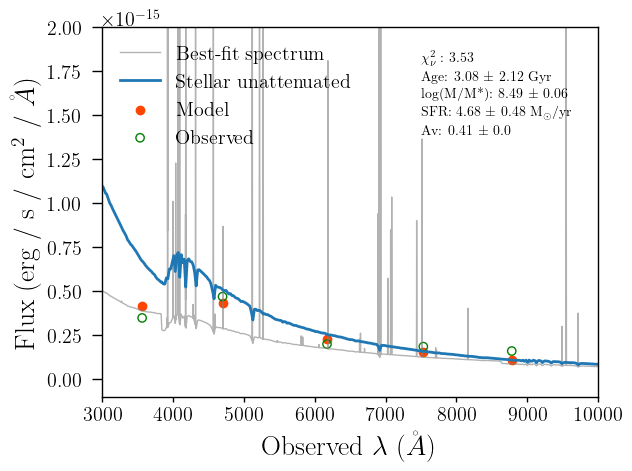

In [21]:
J0023 = fits.open('/home/benjamin/Documents/sed_fitting/old_pop_late_burst/J0023-0948_best_model.fits')

plt.plot(J0023[1].data['wavelength']*10,
         J0023[1].data['L_lambda_total'] * 1e6 / (4 * np.pi * (7.33157e26**2)),
         color='gray', alpha=0.6, lw=1, label='Best-fit spectrum'
)
plt.plot(J0023[1].data['wavelength']*10,
         (J0023[1].data['stellar.young']+J0023[1].data['stellar.old']) * 1e6 / (4 * np.pi * (7.33157e26**2)),
         lw=2, label='Stellar unattenuated'
)

plt.text(7500, 1.8e-15, r'$\chi^{2}_{\nu}:$ '+str(red_chi2))
plt.text(7500, 1.7e-15, 'Age: '+ str(round(age.nominal_value, 2)) + ' ± ' + str(round(age.std_dev, 2)) +' Gyr')
plt.text(7500, 1.6e-15, 'log(M/M*): '+str(round(float(unumpy.nominal_values(mass)), 2)) + ' ± ' + str(round(float(unumpy.std_devs(mass)), 2)))
plt.text(7500, 1.5e-15, 'SFR: '+ str(round(sfr.nominal_value, 2)) + ' ± ' + str(round(sfr.std_dev, 2)) + r' M$_{\odot}$/yr')
plt.text(7500, 1.4e-15, 'Av: '+ str(round(att.nominal_value, 2)) + ' ± ' + str(round(att.std_dev, 2)))
plt.ylabel('Flux (erg / s / cm$^{2}$ / $\AA$)')

plt.xlabel('Observed $\lambda$ ($\AA$)')
plt.scatter(center, flux_model, color='orangered', label='Model')
plt.scatter(center, flux_obs, color='green', facecolor='none', label='Observed')
plt.ylim(-0.1e-15, 2e-15)
plt.xlim(3000, 10000)
plt.legend(loc='upper left')

#plt.plot(J0023_spec['wave'], J0023_spec['flux'])

---

# SED fitting results spectrum

In [20]:
# Cosmology frame to calculate luminosity distances
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

# To read images
from PIL import Image

# Read this galaxy data
gal = 'J0021'
galaxy_id = galnames_ext[np.argmax(np.array(galnames) == gal)]
z_galaxy = z_BN[np.argmax(np.array(galnames) == gal)]

# SDSS wavelengths and filters
center = np.array([0.356505, 0.470033, 0.617448, 0.753363, 0.878169]) * 10000 # wavelength in angstrom
filts = ['u', 'g', 'r', 'i', 'z']

In [24]:
# Reading galaxy model result from CIGALE fit
sed_path = '/home/benjamin/Documents/sed_fitting/'
gal_model = fits.open(sed_path+'constant_sfh_noage/'+galaxy_id+'_best_model.fits')

# Luminosity distance
lum_distance = cosmo.luminosity_distance(z_galaxy) * \
                        (1 * u.cm / (3.24078e-25 * u.Mpc))

# Stellar emission
stellar = (gal_model[1].data['stellar.young'] + gal_model[1].data['stellar.old'] \
         + gal_model[1].data['attenuation.stellar.young'] \
         + gal_model[1].data['attenuation.stellar.old']) \
         * 1e6 / (4 * np.pi * (lum_distance**2)) * 1e18 \
         * (gal_model[1].data['wavelength']*10)**2 / 299792458 / 100

# Extract photometric data and models
mask = (results_noage[1].data['id'] == galaxy_id)

flux_model_mJy = []
flux_obs_mJy = []

flux_model = []
flux_obs = []

# Age in Gyr
age = ufloat(results_noage[1].data['bayes.sfh.age'][mask][0],
             results_noage[1].data['bayes.sfh.age_err'][mask][0]) / 1000

# Stellar mass
mass = upy.log10(ufloat(results_noage[1].data['bayes.stellar.m_star'][mask][0],
                           results_noage[1].data['bayes.stellar.m_star_err'][mask][0]))

# Av extinction
att = 3.1 * ufloat(results_noage[1].data['bayes.attenuation.E_BVs'][mask][0],
                   results_noage[1].data['bayes.attenuation.E_BVs_err'][mask][0])

# Star-formation rate
sfr = ufloat(results_noage[1].data['bayes.sfh.sfr'][mask][0],
             results_noage[1].data['bayes.sfh.sfr_err'][mask][0])

# Reduced Xi squared
red_chi2 = round(results_noage[1].data['best.reduced_chi_square'][mask][0], 2)

# Saving the info in array form
for i in range(len(filts)):
    fl_model_mJy = results_noage[1].data['bayes.'+filts[i]+'_prime'][mask][0]
    flux_model_mJy.append(fl_model_mJy)
    fl_obs_mJy = input_data[filts[i]+'_prime'][mask]
    flux_obs_mJy.append(fl_obs_mJy)
    flux_model.append(1e-18 * fl_model_mJy * 299792458 * 100 / (center[i]**2))
    flux_obs.append(1e-18 * float(fl_obs_mJy) * 299792458 * 100 / (center[i]**2))

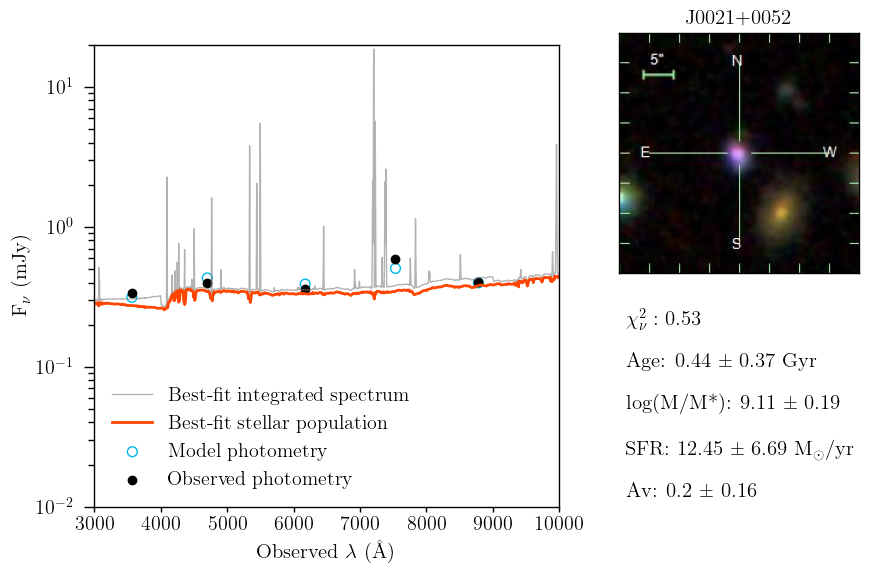

In [26]:
texPlot('on')

fig, main_ax = plt.subplots()
fig.set_size_inches((6,6))

# Plot Best-fit Spectrum
main_ax.plot(gal_model[1].data['wavelength']*10, gal_model[1].data['Fnu'],
        color='gray', alpha=0.6, lw=1, label='Best-fit integrated spectrum')

# Plot Best-fit stellar component
main_ax.plot(gal_model[1].data['wavelength']*10, stellar,
         lw=2, label='Best-fit stellar population', color='orangered')

# Photometry
main_ax.scatter(center, flux_model_mJy, facecolor='none', color=c[0], s=50, label='Model photometry')
main_ax.scatter(center, flux_obs_mJy, color='black', label='Observed photometry')

# Add SDSS stamp
img_stamp = Image.open(magePath+'imges/sdss_stamps/'+gal+'.jpeg')

right_inset_ax = fig.add_axes([1.0, .5, .4, .4], facecolor='w')
right_inset_ax.tick_params(
    axis='both',       # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    left=False,         # ticks along the top edge are off
    labelbottom=False,  # labels along the bottom edge are off
    labelleft=False     # labels along the top edge are off
    
)
right_inset_ax.imshow(img_stamp)

# SED fit results
main_ax.text(11000, 2e-1, r'$\chi^{2}_{\nu}:$ '+str(red_chi2), fontsize=15)
main_ax.text(11000, 1e-1, 'Age: '+ str(round(age.nominal_value, 2)) + ' ± ' + str(round(age.std_dev, 2)) +' Gyr', fontsize=15)
main_ax.text(11000, 5e-2, 'log(M/M*): '+str(round(float(upy.nominal_values(mass)), 2)) + ' ± ' + str(round(float(upy.std_devs(mass)), 2)), fontsize=15)
main_ax.text(11000, 2.3e-2, 'SFR: '+ str(round(sfr.nominal_value, 2)) + ' ± ' + str(round(sfr.std_dev, 2)) + r' M$_{\odot}$/yr', fontsize=15)
main_ax.text(11000, 1.2e-2, 'Av: '+ str(round(att.nominal_value, 2)) + ' ± ' + str(round(att.std_dev, 2)), fontsize=15)

# To rotulate well
main_ax.set_xlim(3000, 10000)
main_ax.set_ylim(1e-2, 20)

main_ax.set_yscale('log')
main_ax.legend(loc='lower left', frameon=False, edgecolor='black')
right_inset_ax.set_title(galaxy_id, fontsize=15)
main_ax.set_ylabel(r'F$_{\nu}$ (mJy)', fontsize=15)
main_ax.set_xlabel(r'Observed $\lambda$ (\AA)', fontsize=15)
#fig.savefig(magePath+'imges/sed_fitting/'+galaxy_id+'_example_noage.pdf', bbox_inches='tight')

---

(3000.0, 10000.0)

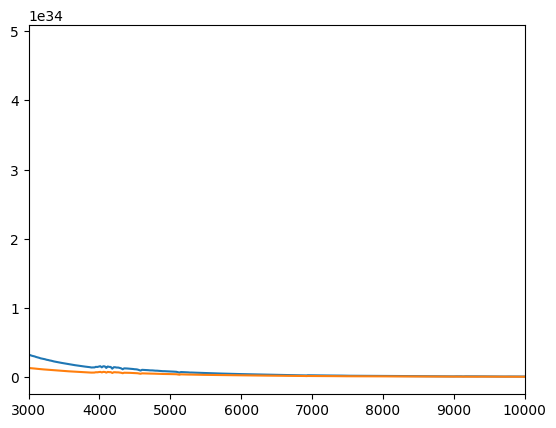

In [35]:
#plt.plot(J0023[1].data['wavelength']*10, J0023[1].data['attenuation.stellar.young'])
#plt.plot(J0023[1].data['wavelength']*10, J0023[1].data['attenuation.stellar.old'])
plt.plot(J0023[1].data['wavelength']*10, J0023[1].data['stellar.young'])
plt.plot(J0023[1].data['wavelength']*10, J0023[1].data['stellar.young'] + J0023[1].data['attenuation.stellar.young'])
#plt.plot(J0023[1].data['wavelength']*10, J0023[1].data['stellar.old'])
plt.xlim(3000, 10000)
#plt.ylim(-0.3e34, 0)

# Balmer absorption

In [11]:
J0023_best_model = fits.open('/home/benjamin/Documents/sed_fitting/constant_sfh_noage/J0023-0948_best_model.fits')

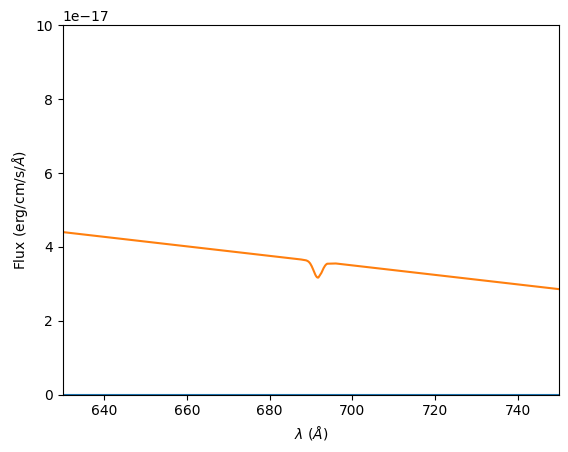

In [13]:
plt.plot(J0023[1].data['wavelength'], J0023[1].data['stellar.young'] / (4 * np.pi * (7.33157e26**2)))
#plt.plot(J0023_best_model[1].data['wavelength'], J0023_best_model[1].data['stellar.old'] / (4 * np.pi * (7.33157e26**2)))
plt.xlabel(r'$\lambda$ ($\AA$)')
plt.ylabel(r'Flux (erg/cm/s/$\AA$)')
plt.xlim(630, 750)
plt.ylim(0, 1e-16)
plt.plot(J0023[1].data['wavelength'], (-0.45e-17/35)*J0023[1].data['wavelength'] + 1.25e-16 + gaussian(J0023[1].data['wavelength']*10, -1.1e-16, 6562.3, 0.054, 10))
#plt.plot(J0023_best_model[1].data['wavelength'], (-0.45e-17/35)*J0023_best_model[1].data['wavelength'] + 1.25e-16, ls='--')
#plt.yscale('log')
#plt.xscale('log')

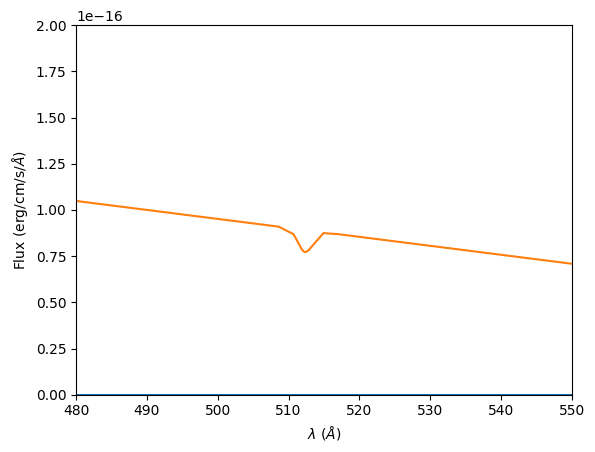

In [14]:
plt.plot(J0023_best_model[1].data['wavelength'],
         J0023_best_model[1].data['stellar.young'] / (4 * np.pi * (7.33157e26**2)))
#plt.plot(J0023_best_model[1].data['wavelength'], J0023_best_model[1].data['stellar.old'] / (4 * np.pi * (7.33157e26**2)))
plt.xlabel(r'$\lambda$ ($\AA$)')
plt.ylabel(r'Flux (erg/cm/s/$\AA$)')
plt.xlim(480, 550)
plt.ylim(0, 2e-16)
plt.plot(J0023_best_model[1].data['wavelength'],
         (-1.7e-17/35)*J0023_best_model[1].data['wavelength'] + 3.38e-16 \
         + gaussian(J0023_best_model[1].data['wavelength']*10, -3e-16, 4861, 0.054, 10))
#plt.plot(J0023_best_model[1].data['wavelength'], (-1.7e-17/35)*J0023_best_model[1].data['wavelength'] + 3.38e-16, ls='--')
#plt.yscale('log')
#plt.xscale('log')